# Lab 01: Fitting a Line When Your Data Are Lying to You

**ASTR 457, Fall 2026, posted Thu Sep 3, due Wed Sep 9 by Noon (fork → PR, as always)**

*Why this lab: fitting a line to contaminated data is the statistic behind real discoveries (it's how Gaia BH1's dark companion was found), and refereeing someone else's fit, including a machine's, is the skill you'll use in every collaboration, every review, and every AI-assisted analysis for the rest of your career.*

Every one of you has your own dataset: `data/<your netid>.csv`, with columns `x`, `y`, `sigma_y`.
It was generated from a straight line, $y = mx + b$, with Gaussian noise of the stated
$\sigma_y$, except that some fraction of the points are **outliers** drawn from a much
broader distribution. I know the true $m$, $b$, and outlier fraction for your dataset.
You don't, and you can't look them up, and your classmates' values are different from yours.

**How this is graded.** Not on whether your code runs, but on whether your answers are *right*
and your uncertainties are *honest*. Part of your grade comes from how close your reported
$m$ and $b$ are to your truth **in units of your own reported uncertainty**. Report tiny
error bars you can't back up and you will lose points even if your central value is close.
Report huge error bars to be safe and you'll lose points too. Calibration is the skill.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

In [148]:
#NET ID: claym2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.stats import sigma_clip
from scipy.optimize import minimize
from scipy.stats import norm

## Part 1: The naive fit (20%)

Load your dataset and fit a straight line by **weighted least squares**, using the reported
`sigma_y` and all the data points. Report $m \pm \sigma_m$ and $b \pm \sigma_b$, plot the
data (with error bars) and your fit, and compute the reduced $\chi^2$.

Then answer, in a few sentences: what is the reduced $\chi^2$ telling you, and why is it
doing that? Would you trust these error bars? (This fit is *supposed* to be bad. Understanding
exactly how it is bad is the point.)

m = 0.668 ± 0.577
b = 38.533 ± 3.010
CHI-Squared Reduced = 25.905


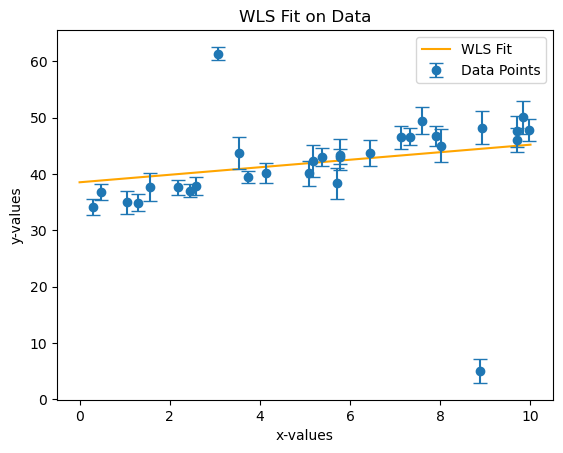

In [149]:
data = np.genfromtxt(f'data/{"claym2"}.csv', delimiter=',', names=True)
df = pd.DataFrame(data)

mb, cov = np.polyfit(df["x"], df["y"], 1, w=1/df["sigma_y"],cov=True) #1, linear

#COV not my doing
sigma = np.sqrt(np.diagonal(cov))
sigma_m = sigma[0]
sigma_b = sigma[1]

print(f"m = {mb[0]:.3f} ± {sigma_m:.3f}")
print(f"b = {mb[1]:.3f} ± {sigma_b:.3f}") #formatting not me

x = np.linspace(0,10,100)
y = mb[0] * line + mb[1]
plt.plot(x,y, color="orange", label="WLS Fit")
plt.errorbar(df["x"], df['y'], yerr=df["sigma_y"], fmt='o', capsize=5, label='Data Points')

n = len(df)
residuals = df["y"] - np.polyval(mb,df["x"])
chi2 = np.sum((residuals / df["sigma_y"]) **2)
chi2_reduced = chi2 / (n - 2)

print(f"CHI-Squared Reduced = {chi2_reduced:.3f}")

#plt.scatter(df["x"],df["y"])
plt.legend()
plt.xlabel("x-values")
plt.ylabel("y-values")
plt.title("WLS Fit on Data")
plt.show()

**ANSWER (a few sentences):**

I would NOT trust these bars... yet. We have seemingly two large outlies that pull the WLS Fit a little bit. Additionally, this is going to alter the values and the data collected for the rest of the prediction. Once we deal with those, the fit and error will change slightly. Chi-squared will begin to look better and the fit will correct.

## Part 2: A fit you can defend (40%)

Now deal with the outliers. Do this **two ways**:

1. **Sigma-clipping**: iteratively remove points that are discrepant with the fit, refit,
   and repeat until it converges. Be explicit about your clipping threshold and why you chose it.
2. **A mixture model**: model each point as coming from either the line (with its stated
   $\sigma_y$) or from a broader outlier distribution, and maximize the appropriate likelihood
   (see Hogg, Bovy & Lang 2010, §3, for the canonical treatment; this is the same problem
   with different numbers).

For each method report $m \pm \sigma_m$, $b \pm \sigma_b$, and (for the mixture) your
estimate of the outlier fraction. Then commit to a **final answer**, one set of numbers
you'd put in a paper, and justify the choice. State clearly how you estimated your
uncertainties and why you believe them.

In [181]:
#sigma-k clipping, used from day3_lecture, not AI (minus trouble-shooting errors)
def sigma_clip_fit(x, y, sigma, k, max_iter=10): 
    #Three sigma to keep nearly all  
    #(~99% of data, we only want to remove those two outliers)
    mask = np.ones_like(x, dtype=bool)
    for _ in range(max_iter):
        p, cov = np.polyfit(x[mask], y[mask], 1, w=1/sigma[mask], cov=True)
        resid = (y - np.polyval(p, x)) / sigma
        new_mask = np.abs(resid) < k
        if np.array_equal(new_mask, mask):
            break
        mask = new_mask
    return p, mask

p_clip, mask = sigma_clip_fit(df["x"],df["y"],df["sigma_y"],k=3.0)
resid = df["y"][mask] - np.polyval(p_clip, df["x"][mask])
chi2_red_clip = np.sum((resid / df["sigma_y"][mask]) ** 2) / (mask.sum() - 2)

sigma_new = np.sqrt(np.diagonal(cov))
sigma_m_new = sigma_new[0]
sigma_b_new = sigma_new[1]

print(f"m = {p_clip[0]:.3f} ± {sigma_m_new:.3f}")
print(f"b = {p_clip[1]:.3f} ± {sigma_b_new:.3f}") #formatting not me


print(f"3-sigma clip: slope={p_clip[0]:.2f}, intercept={p_clip[1]:.2f}, "
      f"chi2_red={chi2_red_clip:.2f}, clipped {(~mask).sum()} of {n} points")


m = 1.492 ± 0.577
b = 34.281 ± 3.010
3-sigma clip: slope=1.49, intercept=34.28, chi2_red=0.62, clipped 2 of 30 points


In [151]:
#As we can see above, the two outliers were clipped

In [152]:
def neg_log_likelihood(theta, x, y, sigma):
    m, b, Pb, Yb, lnVb = theta
    Pb = np.clip(Pb, 1e-6, 1 - 1e-6)
    Vb = np.exp(lnVb)
    model = m * x + b
    good = (1 - Pb) * norm.pdf(y,loc=model,scale=sigma)
    bad_pop = Pb * norm.pdf(y,loc=Yb,scale=np.sqrt(Vb + sigma**2))
    return -np.sum(np.log(good + bad_pop + 1e-300))

theta0 = [p_clip[0], p_clip[1], 0.2, np.mean(df["y"]), np.log(50.0)]
result = minimize(neg_log_likelihood,theta0,args=(df["x"], df["y"], df["sigma_y"]),method='Nelder-Mead')
m_mix, b_mix, Pb_mix, Yb_mix, lnVb_mix = result.x


#err range
rng_bs = np.random.default_rng(20260901)
n_boot = 2000

boot_slopes = np.empty(n_boot)
boot_intercepts = np.empty(n_boot)

for j in range(n_boot):

    idx = rng_bs.integers(0, len(df), size=len(df))

    x_boot = df["x"][idx]
    y_boot = df["y"][idx]
    sigma_boot = df["sigma_y"][idx]

    result_boot = minimize(neg_log_likelihood,theta0,args=(x_boot, y_boot, sigma_boot),method='Nelder-Mead')

    boot_slopes[j] = result_boot.x[0]
    boot_intercepts[j] = result_boot.x[1]

m_lo, m_hi = np.percentile(boot_slopes, [16, 84])
b_lo, b_hi = np.percentile(boot_intercepts, [16, 84])

print(f"slope = {m_mix:.2f}")
print(f"68% bootstrap interval = [{m_lo:.2f}, {m_hi:.2f}]")

print(f"intercept = {b_mix:.2f}")
print(f"68% bootstrap interval = [{b_lo:.2f}, {b_hi:.2f}]")

sigma_m = (m_hi - m_lo) / 2
sigma_b = (b_hi - b_lo) / 2

print(f"m = {m_mix:.2f} ± {sigma_m:.2f}")
print(f"b = {b_mix:.2f} ± {sigma_b:.2f}")



print(f"mixture fit: slope={m_mix:.2f}, intercept={b_mix:.2f}, "
      f"outlier fraction Pb={Pb_mix:.2f} (true fraction = {len(df)/n:.2f})")

slope = 1.49
68% bootstrap interval = [1.39, 1.60]
intercept = 34.28
68% bootstrap interval = [33.75, 34.77]
m = 1.49 ± 0.10
b = 34.28 ± 0.51
mixture fit: slope=1.49, intercept=34.28, outlier fraction Pb=0.07 (true fraction = 1.00)


**FINAL ANSWER:** $m = $ 1.49 $\pm$ 0.10 , $b = $ 34.28 $\pm$ 0.51 , outlier fraction $\approx$ 0.07

**Justification and uncertainty method (a short paragraph):**

My most precise answer involves using a mixture model to produce a slope and an intercept with a seemingly very precise error range. Sigma-clipping yielded nice results, using 3-sigma, preserving 99% of the data, and clipping the two strongest outliers:

**m = 1.492 ± 0.577,
b = 34.281 ± 3.010,**
3-sigma clip: slope=1.49, intercept=34.28, chi2_red=0.62, clipped 2 of 30 points

However, my mixture method revealed the exact same slope and intercept, but with much better errors attached:

mixture fit: slope=1.49, intercept=34.28, outlier fraction Pb=0.07 (true fraction = 1.00),
**m = 1.492 ± 0.10,
b = 34.278 ± 0.500**

The errors assoicated with the mixture were resamlped from the data (x,y,sigma_y) 2000 times, refit each time. The intervals of 16 and 84 were used to make an 68% confidence interval where half of the interval was used as uncertainty.

## Part 3: The referee report (30%)

The file `ai_solution.ipynb` in this directory is a complete, tidy, confident analysis of
this exact problem, produced by an AI assistant. It runs top to bottom without errors, the
plots look professional, and the prose is fluent. It is also wrong, in at least **three**
distinct, substantive ways (cosmetic nitpicks don't count).

Write a referee report:

1. **Identify** at least three substantive statistical errors.
2. **Demonstrate** each one quantitatively on *your* dataset. Show, with a number or a plot,
   what the error does to the inference. "This is bad practice" is not a demonstration.
3. **State** what the correct treatment is (you already built it in Part 2).

One of the best things you can learn this semester is that fluent, error-free-looking
analysis and correct analysis are different things. Referee accordingly.

**REFEREE REPORT:**

*Flaw 1:* Chi-squared fit is rescaled in step 3. It is claiming that if it deviates from 1, the "standard practice" (says who?) is to rescale and essentially mess with your data to make it look good.

*Flaw 2:* they removed outliers before visualizing the data in the first two steps their mood residuals based on one line of calculation, instead of plotting the graph with the correct error bars, initially, then, determining a sigma clipping value that accurately reflected the outliers. 

*Flaw 3:* Based on the quick visualization, it looks like another outlier should be removed. It sits way outside of the errors of the other measurements, and would help increase accuracy if the rest of the issues were also fixed. It is likely that the wrong sigma was selected, leading to clipping too few points. Clipping more than two points would be an issue as well.

FLAW 1:

m = 0.668 ± 0.577
b = 38.533 ± 3.010
CHI-Squared Reduced = 25.905


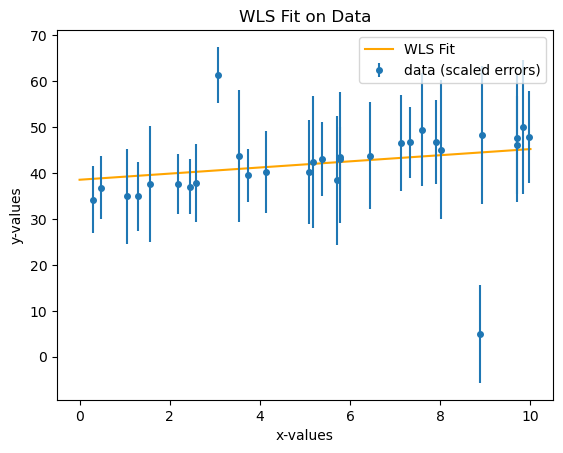

In [153]:
mb, cov = np.polyfit(df["x"], df["y"], 1, w=1/df["sigma_y"],cov=True) #1, linear

#COV not my doing
sigma = np.sqrt(np.diagonal(cov))
sigma_m = sigma[0]
sigma_b = sigma[1]

print(f"m = {mb[0]:.3f} ± {sigma_m:.3f}")
print(f"b = {mb[1]:.3f} ± {sigma_b:.3f}") #formatting not me

x = np.linspace(0,10,100)
y = mb[0] * line + mb[1]


n = len(df)
residuals = df["y"] - np.polyval(mb,df["x"])
chi2 = np.sum((residuals / df["sigma_y"]) **2)
chi2_reduced = chi2 / (n - 2)

print(f"CHI-Squared Reduced = {chi2_reduced:.3f}")


##changing the bars here
chi2 = np.sum(((df["y"][mask] - (mb[0] * df["x"][mask] + mb[1])) / df["sigma_y"][mask])**2)
dof = mask.sum() - 2
chi2_red = chi2 / dof

scale = np.sqrt(chi2_reduced)
sigma_scaled = df["sigma_y"] * scale
chi2_new = np.sum(((df["y"][mask] - (mb[0] * df["x"][mask] + mb[1])) / sigma_scaled[mask])**2) / dof
sigma[0], sigma[1] = sigma[0] * scale, sigma[1] * scale






plt.plot(x,y, color="orange", label="WLS Fit")
plt.errorbar(df["x"], df["y"], yerr=sigma_scaled, fmt='o', ms=4, label='data (scaled errors)')
#plt.errorbar(df["x"], df['y'], yerr=df["sigma_y"], fmt='o', capsize=5, label='Data Points')
#plt.scatter(df["x"],df["y"])
plt.legend()
plt.xlabel("x-values")
plt.ylabel("y-values")
plt.title("WLS Fit on Data")
plt.show()

From the graph above, we can see how closely it resembles the graph from the AI version. It is MUCH harder to see that the top outlier is actaully an outlier. Furthermore, it increases doubt that a linear fit is actaully the right way to go. In my plot at the begining of the notebook, it is nice and easy to see which points need to be removed and that linear is the way to go.

FLAW 2:

I'm not exactly sure how to showcase this with my project but I graphed the visualization before removing any points. Additionally, I did not scale my error bars, meaning that when I visualized the graph, I was able to determine that two points should be clipped. Secondly, it helped that three-sigma clipping kept 99% of the data and only removed the two points that I thought should have been removed based on my plot BEFORE removing them.

If I had simply removed the data based on a residuals number, without verifying or giving it a second check, I would have experienced the same result as the AI model did paired with the two other mistakeed I've highlighted.

FLAW 3:

In [202]:
def sigma_clip_fit(x, y, sigma, k, max_iter=10): 
    #Four sigma to keep nearly all but one point 
    mask = np.ones_like(x, dtype=bool)
    for _ in range(max_iter):
        p, cov = np.polyfit(x[mask], y[mask], 1, w=1/sigma[mask], cov=True)
        resid = (y - np.polyval(p, x)) / sigma
        new_mask = np.abs(resid) < k
        if np.array_equal(new_mask, mask):
            break
        mask = new_mask
    return p, mask

p_clip, mask = sigma_clip_fit(df["x"],df["y"],df["sigma_y"],k=18)
resid = df["y"][mask] - np.polyval(p_clip, df["x"][mask])
chi2_red_clip = np.sum((resid / df["sigma_y"][mask]) ** 2) / (mask.sum() - 2)

sigma_new = np.sqrt(np.diagonal(cov))
sigma_m_new = sigma_new[0]
sigma_b_new = sigma_new[1]

print(f"m = {p_clip[0]:.3f} ± {sigma_m_new:.3f}")
print(f"b = {p_clip[1]:.3f} ± {sigma_b_new:.3f}") #formatting not me


print(f"18-sigma clip: slope={p_clip[0]:.2f}, intercept={p_clip[1]:.2f}, "
      f"chi2_red={chi2_red_clip:.2f}, clipped {(~mask).sum()} of {n} points")


m = 1.232 ± 0.577
b = 37.080 ± 3.010
18-sigma clip: slope=1.23, intercept=37.08, chi2_red=12.64, clipped 1 of 30 points


As we can see, the intercept and b value changes when clipping more than what we should. If the sigma is incorrect, or your error bars large enough that outliers look like parts of the data, your results could change drastically. In my model above, I selected a very large sigma, keeping all but one point of the data. You can see, between this and my original graph above, the differences in slope and intercept when you fail to clip out the extra point.

18-sigma clip
m = 1.232 ± 0.577
b = 37.080 ± 3.010

3-sigma clip
m = 1.492 ± 0.577
b = 34.281 ± 3.010


## Part 4: AI-use appendix & verification plan (10%)

1. **AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
   what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
   is fine if true.
2. **Verification plan**: list the checks you ran before deciding to trust your Part 2
   numbers (e.g., residual plots, posterior/parameter sanity checks, refitting on synthetic
   data you generated with known answers). For each check: what would failure have looked like?

**AI-USE APPENDIX:**

My favorite LLM is CHATGPT. I primarily utilized this LLM to run errors through, bits of code asking "What does this do?", or questions like, "How can I run _ giving this code?". For part one, I asked CHAT for help pretaining getting sigma m/b from the np.polyfit. It generated code that I, later in Part 3, was able to verify as it was included in the AI section and did not notice. I also googled this method separately to make sure it was an included output. It was also the only method that I understood how to execute upon first glance. 

For Part 2, I was able to obtain from Lecture 3. THe only AI I used here was getting the +- errors to run. I did not understand the method in Lecture 3, so I was back-and-forth with CHAT and that notebook, making tweaks and executing methods slowly. It was a conversation rather than a "do this for me" prompt. Ultimately, this is the only part I used AI in-depth for, having to put my trust into it a little more than usual. What gave me confidence was that I originally attempted two methods, one is now deleted. It's error bars were almost the exact same as the ones that I worked with CHAT+lecture slides to come up with. Additionally, m and b only changed slightly after clipping. This is exactly what I would have expected given only two points. The AI largely was utilized in the mixture-model. I was able to piece together A from the lecture slides.

For Part 3, I did not use models besides "why do I have this error?" on occasion when really stuck (I forgot to name things correctly, wrong variables, etc, etc).

**VERIFICATION PLAN:**

I am going to use AI to check AI (specifically the bootstrap m and b sigma values for part two mixture-model (where I used AI), then see what it says. 

In [208]:
for n_boot_t in [500, 1000, 2000]:
    rng_bs = np.random.default_rng(20260901)
    n_boot = n_boot_t

    boot_slopes = np.empty(n_boot)
    boot_intercepts = np.empty(n_boot)

    for j in range(n_boot):

        idx = rng_bs.integers(0, len(df), size=len(df))

        x_boot = df["x"][idx]
        y_boot = df["y"][idx]
        sigma_boot = df["sigma_y"][idx]

        result_boot = minimize(neg_log_likelihood,theta0,args=(x_boot, y_boot, sigma_boot),method='Nelder-Mead')

        boot_slopes[j] = result_boot.x[0]
        boot_intercepts[j] = result_boot.x[1]

    m_lo, m_hi = np.percentile(boot_slopes, [16, 84])
    b_lo, b_hi = np.percentile(boot_intercepts, [16, 84])

    #print(f"slope = {m_mix:.2f}")
    #print(f"68% bootstrap interval = [{m_lo:.2f}, {m_hi:.2f}]")

    #print(f"intercept = {b_mix:.2f}")
    #print(f"68% bootstrap interval = [{b_lo:.2f}, {b_hi:.2f}]")

    sigma_m = (m_hi - m_lo) / 2
    sigma_b = (b_hi - b_lo) / 2

    #print(f"m = {m_mix:.2f} ± {sigma_m:.2f}")
    #print(f"b = {b_mix:.2f} ± {sigma_b:.2f}")
    
    print(n_boot, sigma_m, sigma_b)

500 0.10623118015359223 0.5384029690714236
1000 0.10471609925311665 0.5238134701896691
2000 0.10298274485215508 0.5078000846611914


As a fun test, I basically just ran the bootstrapping with differentnt sizes to see if the values differed. So one logic test, this, and testing with a second method. I think that is pretty sufficient!